Dataset Loaded Successfully!
Rows: 7043, Columns: 21


/tmp/ipython-input-31537576.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)



Training Logistic Regression...
Training KNN...

Results:
Logistic Regression Accuracy: 82.04%
KNN Accuracy: 77.15%

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



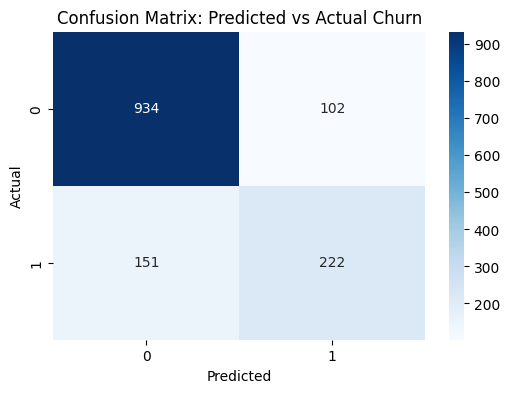

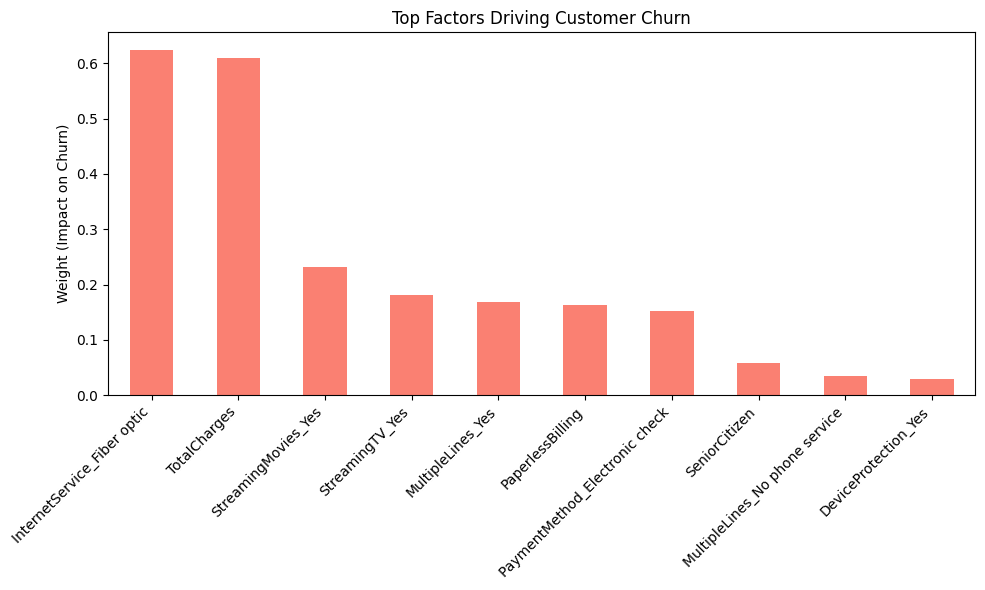

In [2]:
# ==========================================
# PROJECT: Customer Churn Prediction
# AUTHOR: Baqar Hussain Momin
# ==========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Data
# Make sure the filename matches exactly what you uploaded
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset Loaded Successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 3. Data Cleaning (The "Pre-processing" Bullet Point)
# Convert 'TotalCharges' to numeric (it has some blank strings that cause errors)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

# Drop 'customerID' (It's just a random ID, not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

# 4. Feature Engineering (The "One-Hot Encoding" Bullet Point)
# We convert text categories (like "Male", "Yes") into numbers (0, 1)
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        if len(df[column].unique()) <= 2:
            # Binary columns (Yes/No)
            df[column] = le.fit_transform(df[column])
        else:
            # Multi-category columns (e.g., Payment Method) -> Create dummy variables
            df = pd.get_dummies(df, columns=[column], drop_first=True)

# 5. Define Features (X) and Target (y)
X = df.drop('Churn', axis=1) # All columns except Churn
y = df['Churn']              # The target we want to predict

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (Crucial for KNN algorithm performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Train Models (The "Algorithm" Bullet Point)

# Model A: Logistic Regression
print("\nTraining Logistic Regression...")
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Model B: K-Nearest Neighbors (KNN)
print("Training KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# 7. Evaluate & Visualize (The "Business Impact" Bullet Point)
acc_log = accuracy_score(y_test, y_pred_log)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"\nResults:")
print(f"Logistic Regression Accuracy: {acc_log*100:.2f}%")
print(f"KNN Accuracy: {acc_knn*100:.2f}%")

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_log))

# --- VISUAL 1: Confusion Matrix ---
# This shows how many churners we correctly caught
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual Churn')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- VISUAL 2: Feature Importance ---
# This proves the "Fiber Optic users churn more" insight
weights = pd.Series(log_model.coef_[0], index=X.columns)
plt.figure(figsize=(10,6))
weights.sort_values(ascending=False)[:10].plot(kind='bar', color='salmon')
plt.title('Top Factors Driving Customer Churn')
plt.ylabel('Weight (Impact on Churn)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()